original prototype demo notebook

# Seeded random-access preferential-attachment VAE

Can a shared latent make graph-specific preferential-attachment decisions available through
`parent(seed, query)` without replaying earlier arrivals? This notebook implements a transparent
baseline, not a novel architecture and not an exact replacement for the NetworkX simulator.

The representation `[-1, 1, 1, 1, 3, 1]` means edges `(2,1), (3,1), (4,1), (5,3), (6,1)`.
Node IDs are arrival IDs. The root and initial edge are fixed; nodes 3 onward are learned.

In [ ]:
# Install if needed: pip install numpy torch networkx matplotlib
import copy, hashlib, json, math, platform, random, time
from dataclasses import asdict, dataclass
from pathlib import Path
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import torch
from torch import nn
from torch.nn import functional
from torch.utils.data import DataLoader, TensorDataset


@dataclass(frozen=True)
class Config:
    profile: str
    num_nodes: int
    latent_dim: int
    hidden: int
    train_graphs: int
    val_graphs: int
    test_graphs: int
    generated_graphs: int
    batch_size: int
    epochs: int
    lr: float = 1e-3
    beta: float = 1.0
    warmup_epochs: int = 10
    init_seed: int = 20260909
    threads: int = 8


PROFILES = {
    "smoke": Config(
        profile="smoke",
        num_nodes=16,
        latent_dim=8,
        hidden=64,
        train_graphs=128,
        val_graphs=32,
        test_graphs=64,
        generated_graphs=64,
        batch_size=32,
        epochs=2,
        warmup_epochs=1,
        threads=2,
    ),
    "demo": Config(
        profile="demo",
        num_nodes=64,
        latent_dim=64,
        hidden=256,
        train_graphs=2_048,
        val_graphs=256,
        test_graphs=512,
        generated_graphs=512,
        batch_size=64,
        epochs=30,
    ),
    # 16x the demo training data, a wider model, and over 3x the epochs.
    "large": Config(
        profile="large",
        num_nodes=64,
        latent_dim=128,
        hidden=512,
        train_graphs=32_768,
        val_graphs=4_096,
        test_graphs=4_096,
        generated_graphs=2_048,
        batch_size=256,
        epochs=100,
        warmup_epochs=15,
        threads=8,
    ),
}
RUN_PROFILE = "large"  # Change to 'smoke' first when testing a new environment.
cfg = PROFILES[RUN_PROFILE]
torch.set_num_threads(cfg.threads)
random.seed(cfg.init_seed)
np.random.seed(cfg.init_seed)
torch.manual_seed(cfg.init_seed)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(
    {
        "config": asdict(cfg),
        "device": str(device),
        "platform": platform.platform(),
        "numpy": np.__version__,
        "torch": torch.__version__,
        "networkx": nx.__version__,
        "matplotlib": plt.matplotlib.__version__,
    }
)

{'config': {'profile': 'large', 'num_nodes': 64, 'latent_dim': 128, 'hidden': 512, 'train_graphs': 32768, 'val_graphs': 4096, 'test_graphs': 4096, 'generated_graphs': 2048, 'batch_size': 256, 'epochs': 100, 'lr': 0.001, 'beta': 1.0, 'warmup_epochs': 15, 'init_seed': 20260909, 'threads': 8}, 'device': 'cuda', 'platform': 'Linux-7.2.3-arch1-3-x86_64-with-glibc2.44', 'numpy': '2.5.3', 'torch': '2.14.0+cu130', 'networkx': '3.6.1', 'matplotlib': '3.11.1'}


## Simulation and representation

NetworkX runs the sequential reference process. The encoder never receives simulator seeds.
Prefix reconstruction retains only arrivals up to the requested cutoff.

In [ ]:
def simulate_graph(num_nodes, simulator_seed):
    if num_nodes < 2:
        raise ValueError("num_nodes must be at least 2")
    initial_graph = nx.Graph()
    initial_graph.add_edge(0, 1)
    graph = nx.barabasi_albert_graph(
        num_nodes, m=1, seed=int(simulator_seed), initial_graph=initial_graph
    )
    zero_based_to_arrival_id = {
        zero_based_id: zero_based_id + 1 for zero_based_id in range(num_nodes)
    }
    return nx.relabel_nodes(graph, zero_based_to_arrival_id)


def parents_to_graph(parents, through_node=None):
    parents = np.asarray(parents)
    through_node = len(parents) if through_node is None else int(through_node)
    if not 1 <= through_node <= len(parents):
        raise ValueError("invalid prefix")
    graph = nx.Graph()
    graph.add_nodes_from(range(1, through_node + 1))
    for node in range(2, through_node + 1):
        graph.add_edge(node, int(parents[node - 1]))
    return graph


def graph_to_parents(graph):
    num_nodes = len(graph)
    parents = np.full(num_nodes, -1, dtype=np.int64)
    parents[1] = 1
    for node in range(3, num_nodes + 1):
        older_neighbors = [
            neighbor for neighbor in graph.neighbors(node) if neighbor < node
        ]
        assert len(older_neighbors) == 1
        parents[node - 1] = older_neighbors[0]
    validate_parents(parents)
    return parents


def validate_parents(parents):
    parents = np.asarray(parents)
    num_nodes = len(parents)
    assert parents[0] == -1 and parents[1] == 1
    assert all(1 <= int(parents[node - 1]) < node for node in range(2, num_nodes + 1))


for seed in range(8):
    graph = simulate_graph(cfg.num_nodes, seed)
    parents = graph_to_parents(graph)
    reconstructed_graph = parents_to_graph(parents)
    assert set(map(frozenset, graph.edges())) == set(
        map(frozenset, reconstructed_graph.edges())
    )
print("Simulator and labeled-edge round trips passed.")

Simulator and labeled-edge round trips passed.


{'train': (32768, 64), 'validation': (4096, 64), 'test': (4096, 64)}


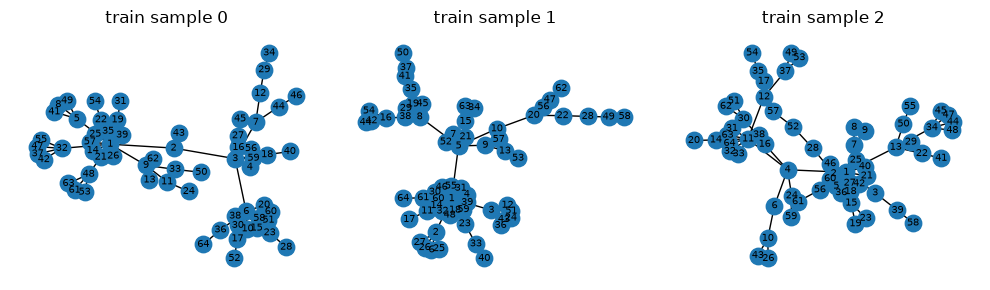

In [ ]:
def make_split(num_graphs, first_seed):
    parent_arrays = []
    for seed_offset in range(num_graphs):
        simulator_seed = first_seed + seed_offset
        graph = simulate_graph(cfg.num_nodes, simulator_seed)
        parent_arrays.append(graph_to_parents(graph))

    return torch.from_numpy(np.stack(parent_arrays))


train_p = make_split(cfg.train_graphs, 0)
val_p = make_split(cfg.val_graphs, 1_000_000)
test_p = make_split(cfg.test_graphs, 2_000_000)
loader_options = {"num_workers": 0, "pin_memory": device.type == "cuda"}
train_loader = DataLoader(
    TensorDataset(train_p),
    batch_size=cfg.batch_size,
    shuffle=True,
    generator=torch.Generator().manual_seed(cfg.init_seed),
    **loader_options,
)
val_loader = DataLoader(
    TensorDataset(val_p), batch_size=cfg.batch_size, shuffle=False, **loader_options
)
print(
    {
        split_name: tuple(parent_data.shape)
        for split_name, parent_data in {
            "train": train_p,
            "validation": val_p,
            "test": test_p,
        }.items()
    }
)

figure, axes = plt.subplots(1, 3, figsize=(10, 3))
for sample_index, axis in enumerate(axes):
    graph = parents_to_graph(train_p[sample_index].numpy())
    node_positions = nx.spring_layout(graph, seed=17)
    nx.draw(
        graph,
        node_positions,
        ax=axis,
        node_size=140,
        with_labels=True,
        font_size=7,
    )
    axis.set_title(f"train sample {sample_index}")
plt.tight_layout()
plt.show()

## Query-conditioned VAE

For batch size (B), there are (Q=N-2) learned queries. The encoder sees a flattened
`[B,Q,N]` one-hot parent representation. It returns `mu, logvar` in `[B,D]`. One sampled
latent is reused for every query. The decoder applies the same MLP independently to each
`[latent, query-one-hot]`; there is no query-to-query communication.

`std = exp(0.5*logvar)` converts log variance to standard deviation, then
`z = mu + std*epsilon` with coordinatewise standard-normal `epsilon`. Log variance is clamped
to `[-10,10]` for stability.

In [ ]:
class QueryVAE(nn.Module):
    def __init__(self, num_nodes, latent_dim, hidden_dim):
        super().__init__()
        self.num_nodes = num_nodes
        self.latent_dim = latent_dim
        self.encoder = nn.Sequential(
            nn.Linear((num_nodes - 2) * num_nodes, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
        )
        self.mean_head = nn.Linear(hidden_dim, latent_dim)
        self.log_variance_head = nn.Linear(hidden_dim, latent_dim)
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim + num_nodes, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, num_nodes),
        )

    def encode(self, parents):
        # Root sentinel and fixed node 2 are sliced out before one-hot encoding.
        encoded_parents = (
            functional.one_hot(parents[:, 2:] - 1, num_classes=self.num_nodes)
            .float()
            .flatten(1)
        )
        hidden_features = self.encoder(encoded_parents)
        latent_mean = self.mean_head(hidden_features)
        latent_log_variance = self.log_variance_head(hidden_features).clamp(-10, 10)
        return latent_mean, latent_log_variance

    def decode(self, latent, queries):
        batch_size = latent.shape[0]
        num_queries = queries.numel()
        query_encoding = (
            functional.one_hot(queries - 1, num_classes=self.num_nodes)
            .float()
            .unsqueeze(0)
            .expand(batch_size, -1, -1)
        )
        repeated_latent = latent[:, None, :].expand(-1, num_queries, -1)
        raw_logits = self.decoder(torch.cat([repeated_latent, query_encoding], -1))
        valid_parent_mask = (
            torch.arange(1, self.num_nodes + 1, device=raw_logits.device)[None, None, :]
            < queries[None, :, None]
        )
        masked_logits = raw_logits.masked_fill(~valid_parent_mask, float("-inf"))
        return raw_logits, masked_logits, valid_parent_mask

    def forward(self, parents, epsilon=None):
        latent_mean, latent_log_variance = self.encode(parents)
        latent_std = torch.exp(0.5 * latent_log_variance)
        noise = torch.randn_like(latent_std) if epsilon is None else epsilon
        latent = latent_mean + latent_std * noise
        return (
            *self.decode(
                latent,
                torch.arange(3, self.num_nodes + 1, device=parents.device),
            ),
            latent_mean,
            latent_log_variance,
            latent,
        )


def loss_parts(model, parents, epsilon=None):
    outputs = model(parents, epsilon)
    raw_logits, masked_logits, valid_parent_mask = outputs[:3]
    latent_mean, latent_log_variance, latent = outputs[3:]
    target_parents = parents[:, 2:] - 1
    batch_size, num_queries = target_parents.shape
    cross_entropy_per_query = functional.cross_entropy(
        masked_logits.reshape(batch_size * num_queries, cfg.num_nodes),
        target_parents.reshape(-1),
        reduction="none",
    ).reshape(batch_size, num_queries)
    reconstruction_loss = cross_entropy_per_query.sum(1)
    kl_divergence = 0.5 * (
        latent_mean.square() + latent_log_variance.exp() - 1 - latent_log_variance
    ).sum(1)
    diagnostics = (
        raw_logits,
        masked_logits,
        valid_parent_mask,
        latent_mean,
        latent_log_variance,
        latent,
    )
    return reconstruction_loss, kl_divergence, cross_entropy_per_query, diagnostics


model = QueryVAE(cfg.num_nodes, cfg.latent_dim, cfg.hidden).to(device)
sample = train_p[:4].to(device)
reconstruction_loss, kl_divergence, cross_entropy_per_query, diagnostics = loss_parts(
    model, sample
)
(
    raw_logits,
    masked_logits,
    valid_parent_mask,
    latent_mean,
    latent_log_variance,
    latent,
) = diagnostics
assert raw_logits.shape == (4, cfg.num_nodes - 2, cfg.num_nodes)
assert valid_parent_mask.shape == (1, cfg.num_nodes - 2, cfg.num_nodes)
assert (
    torch.isfinite(raw_logits).all()
    and torch.isfinite(masked_logits[valid_parent_mask.expand_as(masked_logits)]).all()
)
assert torch.isfinite(reconstruction_loss).all()
assert not valid_parent_mask[..., -1].any()
(reconstruction_loss.mean() + kl_divergence.mean()).backward()
assert all(
    torch.isfinite(parameter.grad).all()
    for parameter in model.parameters()
    if parameter.grad is not None
)
model.zero_grad(set_to_none=True)
print(
    {
        "raw_logits": tuple(raw_logits.shape),
        "latent_mean": tuple(latent_mean.shape),
        "latent": tuple(latent.shape),
        "cross_entropy": tuple(cross_entropy_per_query.shape),
    }
)

{'raw_logits': (4, 62, 64), 'latent_mean': (4, 128), 'latent': (4, 128), 'cross_entropy': (4, 62)}


Each query cross-entropy is (-\log p(\text{correct parent})). It is summed over queries for
one graph. KL is summed over latent coordinates exactly once per graph. Their beta-weighted sum
is averaged over graphs. At beta 1 this is a one-sample estimate of the negative ELBO, not exact
marginal graph negative log likelihood. Validation uses fixed posterior noise and beta 1 for
checkpoint selection; mean-latent reconstruction is reported separately.

{'epoch': 1, 'beta': 0.06666666666666667, 'train_recon_query': 3.011870370757195, 'train_kl_graph': 8.640387966355775, 'val_recon_query': 2.9465774259259625, 'val_kl_graph': 15.493662476539612}
{'epoch': 2, 'beta': 0.13333333333333333, 'train_recon_query': 2.9289225705208315, 'train_kl_graph': 12.367576889693737, 'val_recon_query': 2.9031448979531564, 'val_kl_graph': 12.820009589195251}
{'epoch': 3, 'beta': 0.2, 'train_recon_query': 2.897387162331612, 'train_kl_graph': 10.819464318454266, 'val_recon_query': 2.879946893261325, 'val_kl_graph': 11.067736089229584}
{'epoch': 4, 'beta': 0.26666666666666666, 'train_recon_query': 2.8769950809017306, 'train_kl_graph': 10.204598873853683, 'val_recon_query': 2.8623695527353594, 'val_kl_graph': 10.798292458057404}
{'epoch': 5, 'beta': 0.3333333333333333, 'train_recon_query': 2.8615250491326853, 'train_kl_graph': 10.176343955099583, 'val_recon_query': 2.8539005248777327, 'val_kl_graph': 10.551689088344574}
{'epoch': 6, 'beta': 0.4, 'train_recon_qu

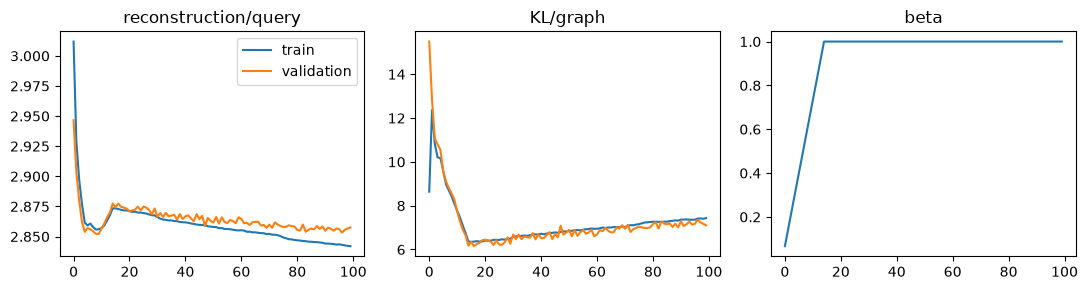

In [ ]:
optimizer = torch.optim.Adam(model.parameters(), lr=cfg.lr)
fixed_val_eps = torch.randn(
    cfg.val_graphs, cfg.latent_dim, generator=torch.Generator().manual_seed(314159)
)
history = []
best = None
best_obj = float("inf")
initial = copy.deepcopy(model.state_dict())
started = time.perf_counter()
for epoch in range(cfg.epochs):
    model.train()
    train_reconstruction_total = 0
    train_kl_total = 0
    num_train_graphs_seen = 0
    beta = cfg.beta * min(1.0, (epoch + 1) / cfg.warmup_epochs)
    for (parent_batch,) in train_loader:
        parent_batch = parent_batch.to(device, non_blocking=True)
        reconstruction_loss, kl_divergence, _, _ = loss_parts(model, parent_batch)
        loss = (reconstruction_loss + beta * kl_divergence).mean()
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        train_reconstruction_total += reconstruction_loss.sum().item()
        train_kl_total += kl_divergence.sum().item()
        num_train_graphs_seen += len(parent_batch)
    model.eval()
    validation_reconstruction_total = 0
    validation_kl_total = 0
    num_validation_graphs_seen = 0
    noise_offset = 0
    with torch.no_grad():
        for (parent_batch,) in val_loader:
            batch_size = len(parent_batch)
            epsilon = fixed_val_eps[noise_offset : noise_offset + batch_size].to(
                device, non_blocking=True
            )
            noise_offset += batch_size
            parent_batch = parent_batch.to(device, non_blocking=True)
            reconstruction_loss, kl_divergence, _, _ = loss_parts(
                model, parent_batch, epsilon
            )
            validation_reconstruction_total += reconstruction_loss.sum().item()
            validation_kl_total += kl_divergence.sum().item()
            num_validation_graphs_seen += batch_size
    row = {
        "epoch": epoch + 1,
        "beta": beta,
        "train_recon_query": train_reconstruction_total
        / num_train_graphs_seen
        / (cfg.num_nodes - 2),
        "train_kl_graph": train_kl_total / num_train_graphs_seen,
        "val_recon_query": validation_reconstruction_total
        / num_validation_graphs_seen
        / (cfg.num_nodes - 2),
        "val_kl_graph": validation_kl_total / num_validation_graphs_seen,
    }
    history.append(row)
    validation_objective = (
        validation_reconstruction_total + validation_kl_total
    ) / num_validation_graphs_seen
    if epoch + 1 >= cfg.warmup_epochs and validation_objective < best_obj:
        best_obj = validation_objective
        best = copy.deepcopy(model.state_dict())
    print(row)
assert best is not None
assert any(
    not torch.equal(initial[name].cpu(), model.state_dict()[name].cpu())
    for name in initial
)
model.load_state_dict(best)
elapsed = time.perf_counter() - started
print(
    f"training seconds: {elapsed:.3f}; selected validation objective/graph: {best_obj:.4f}"
)

# Preserve the expensive run. The decoder state plus configuration is sufficient for inference.
artifact_dir = Path("artifacts")
artifact_dir.mkdir(exist_ok=True)
checkpoint_path = artifact_dir / f"seeded_pa_vae_{cfg.profile}_best.pt"
torch.save(
    {
        "decoder_state_dict": {
            name: value.detach().cpu()
            for name, value in model.decoder.state_dict().items()
        },
        "model_state_dict": {
            name: value.detach().cpu() for name, value in model.state_dict().items()
        },
        "config": asdict(cfg),
        "history": history,
        "best_validation_objective_per_graph": best_obj,
    },
    checkpoint_path,
)
print("saved checkpoint:", checkpoint_path.resolve())

figure, axes = plt.subplots(1, 3, figsize=(11, 3))
axes[0].plot([record["train_recon_query"] for record in history], label="train")
axes[0].plot([record["val_recon_query"] for record in history], label="validation")
axes[0].set_title("reconstruction/query")
axes[0].legend()
axes[1].plot([record["train_kl_graph"] for record in history], label="train")
axes[1].plot([record["val_kl_graph"] for record in history], label="validation")
axes[1].set_title("KL/graph")
axes[2].plot([record["beta"] for record in history])
axes[2].set_title("beta")
plt.tight_layout()
plt.show()

## Frozen seed-and-query interface

SHA-256 turns canonical `(version, seed, role, query)` records into independent PCG64 keys.
The scalar path is authoritative and always uses a CPU float32 decoder. It neither calls the
encoder nor simulator and it stores no graph. Its dense output head still scales with configured N.

In [ ]:
def keyed_rng(seed, role, query=None):
    if isinstance(seed, bool) or not isinstance(seed, (int, np.integer)) or seed < 0:
        raise ValueError("seed must be a nonnegative integer")
    payload = json.dumps(
        ["pa-demo-v1", str(int(seed)), role, None if query is None else int(query)],
        separators=(",", ":"),
    ).encode()
    key = int.from_bytes(hashlib.sha256(payload).digest()[:8], "little", signed=False)
    return np.random.Generator(np.random.PCG64(key))


class SeededPAGenerator:
    def __init__(self, decoder, num_nodes, latent_dim):
        self.num_nodes = int(num_nodes)
        self.latent_dim = int(latent_dim)
        self.decoder = copy.deepcopy(decoder).cpu().float().eval()
        for parameter in self.decoder.parameters():
            parameter.requires_grad_(False)

    def _check_query(self, query):
        if (
            isinstance(query, bool)
            or not isinstance(query, (int, np.integer))
            or not 1 <= int(query) <= self.num_nodes
        ):
            raise ValueError(f"query must be an integer in 1..{self.num_nodes}")

    def parent(self, seed, query):
        self._check_query(query)
        query = int(query)
        if query == 1:
            return None
        if query == 2:
            return 1

        # This is the noise we are going to decode
        latent = torch.from_numpy(keyed_rng(seed, "latent")
            .standard_normal(self.latent_dim)
            .astype(np.float32))[None, :]

        # Create a one hot encoding of the query node to concatenate with the latent vector for decoding
        query_encoding = functional.one_hot(torch.tensor([query - 1]), num_classes=self.num_nodes).float()

        with torch.no_grad():
            logits = self.decoder(torch.cat([latent, query_encoding], 1))[
                0, : query - 1
            ]

        # Perform deterministic categorical sampling:
        # we sample deterministically from the distribution so different seeds can produce different graphs
        # We do this instead of just choosing the most probable parent because we want to model the stochastic
        # nature of real growth graphs; the most common parent will probably create an overly concentrated graph on the firs tnoe
        # This is a little different from the original idea: the seed selects on graph, and the decoder reveals it.
        # you could try to do argmax sampling and see it's behavior...the difference between the two is that we are shifting some of the character of the graph over 
        # to the decoder and noise. Here we are exploring if the latent just adjusted probability distributions from which many different graphs could be sampled, as opposed to 
        # having the shared latent specifically select one graph. Both could be interesting to explore.
        probabilities = torch.softmax(logits, 0).double().numpy()

        assert np.isfinite(probabilities).all() and np.all(probabilities > 0)

        # Compute cumulative distribution
        # This gives us a range 0-1 of intervals we can sample from.
        cumulative_probabilities = np.cumsum(probabilities, dtype=np.float64)
        cumulative_probabilities[-1] = 1.0

        # Create a reproducible RNG based on the seed, role, and query. This ensures that the same seed and query will always produce the same parent.
        uniform_sample = keyed_rng(seed, "parent", query).random()
        # Figure out the index of the parent by finding where the uniform sample falls in the cumulative distribution.
        parent_index = np.searchsorted(
            cumulative_probabilities, uniform_sample, side="right"
        )
        return int(parent_index + 1)

    def parents(self, seed, queries):
        return [self.parent(seed, query) for query in queries]

    def graph(self, seed):
        parents = np.array(
            [-1] + [self.parent(seed, query) for query in range(2, self.num_nodes + 1)],
            dtype=np.int64,
        )
        validate_parents(parents)
        return parents_to_graph(parents)


generator = SeededPAGenerator(model.decoder, cfg.num_nodes, cfg.latent_dim)
queries = list(range(1, cfg.num_nodes + 1))
expected = generator.parents(123, queries)

for order in [
    queries,
    queries[::-1],
    np.random.default_rng(4).permutation(queries).tolist(),
    [5, 3, 5, 9, 3],
]:
    got = generator.parents(123, order)
    assert got == [expected[query - 1] for query in order]

for query in queries:
    assert generator.parent(123, query) == generator.parent(123, query)

interleaved = [generator.parent(seed, query) for query in queries for seed in [123, 456]]

assert interleaved == [generator.parent(seed, query) for query in queries for seed in [123, 456]]

state = {name: value.cpu().clone() for name, value in model.decoder.state_dict().items()}

reloaded = copy.deepcopy(model.decoder).cpu()
reloaded.load_state_dict(state)
generator2 = SeededPAGenerator(reloaded, cfg.num_nodes, cfg.latent_dim)
assert generator2.parents(123, queries) == expected
assert set(map(frozenset, generator.graph(123).edges())) == set(
    map(frozenset, generator2.graph(123).edges())
)
print(
    "Determinism, query-order, reload-without-encoder, and tree assertions passed.",
    expected,
)

Determinism, query-order, reload-without-encoder, and tree assertions passed. [None, 1, 1, 2, 3, 2, 4, 2, 4, 1, 5, 5, 9, 10, 12, 2, 11, 11, 2, 8, 8, 2, 2, 23, 2, 11, 11, 9, 1, 2, 2, 24, 3, 2, 14, 2, 2, 5, 35, 8, 6, 21, 10, 11, 3, 1, 11, 2, 2, 35, 11, 8, 5, 11, 38, 2, 9, 2, 32, 2, 1, 7, 2, 4]


## Independent-parent baseline

This uses smoothed parent marginals estimated only from training graphs. It is deterministic per
`(seed,query)` but has no graph-level shared latent, so it deliberately removes learned dependence.

simple baseline used to compare, just computes the distributions of nodes in the training data, and then samples from them. But it also incorporates seeding as well to be comporable sample wise. It's a reproducible random draw.

There's a big significance with this: all this does it learn the average parent probabilites for each query position, and then samples them. It tries to do everythign the same, but just removes z from the equation. It's like pure average behavior of these graphs, as opposed to some specific graph latent.

I do think we need a different baseline to compare against though...maybe some kind of markov model or something.

In [ ]:
class IndependentParentGenerator:
    def __init__(self, training):
        self.num_nodes = training.shape[1]
        self.probabilities = {}
        for query in range(3, self.num_nodes + 1):
            counts = np.full(query - 1, 0.5, dtype=np.float64)
            for parent in training[:, query - 1].numpy():
                counts[parent - 1] += 1
            self.probabilities[query] = counts / counts.sum()

    def parent(self, seed, query):
        if (
            not isinstance(query, (int, np.integer))
            or isinstance(query, bool)
            or not 1 <= int(query) <= self.num_nodes
        ):
            raise ValueError("invalid query")
        if query == 1:
            return None
        if query == 2:
            return 1
        cumulative_probabilities = np.cumsum(
            self.probabilities[int(query)], dtype=np.float64
        )
        cumulative_probabilities[-1] = 1.0
        uniform_sample = keyed_rng(seed, "parent", int(query)).random()
        return int(
            np.searchsorted(cumulative_probabilities, uniform_sample, side="right") + 1
        )

    def graph(self, seed):
        parents = np.array(
            [-1] + [self.parent(seed, query) for query in range(2, self.num_nodes + 1)]
        )
        validate_parents(parents)
        return parents_to_graph(parents)


baseline = IndependentParentGenerator(train_p)
for query in range(3, cfg.num_nodes + 1):
    query_probabilities = baseline.probabilities[query]
    assert len(query_probabilities) == query - 1
    assert np.isclose(query_probabilities.sum(), 1)

## Reconstruction, distributional diagnostics, and timing

Fresh VAE graphs use prior latents through the public API; test graphs are never encoded for
generation. The reinforcement diagnostic compares node 1's degree halfway through growth with
its later degree gain. Bootstrap intervals resample whole graphs. A degree plot alone is not
evidence that the joint growth process was learned.

{'mean_latent_test_parent_accuracy': 0.23049236834049225, 'mean_latent_test_cross_entropy': 2.798771381378174, 'note': 'reconstruction diagnostic; not fresh generation or marginal likelihood'}


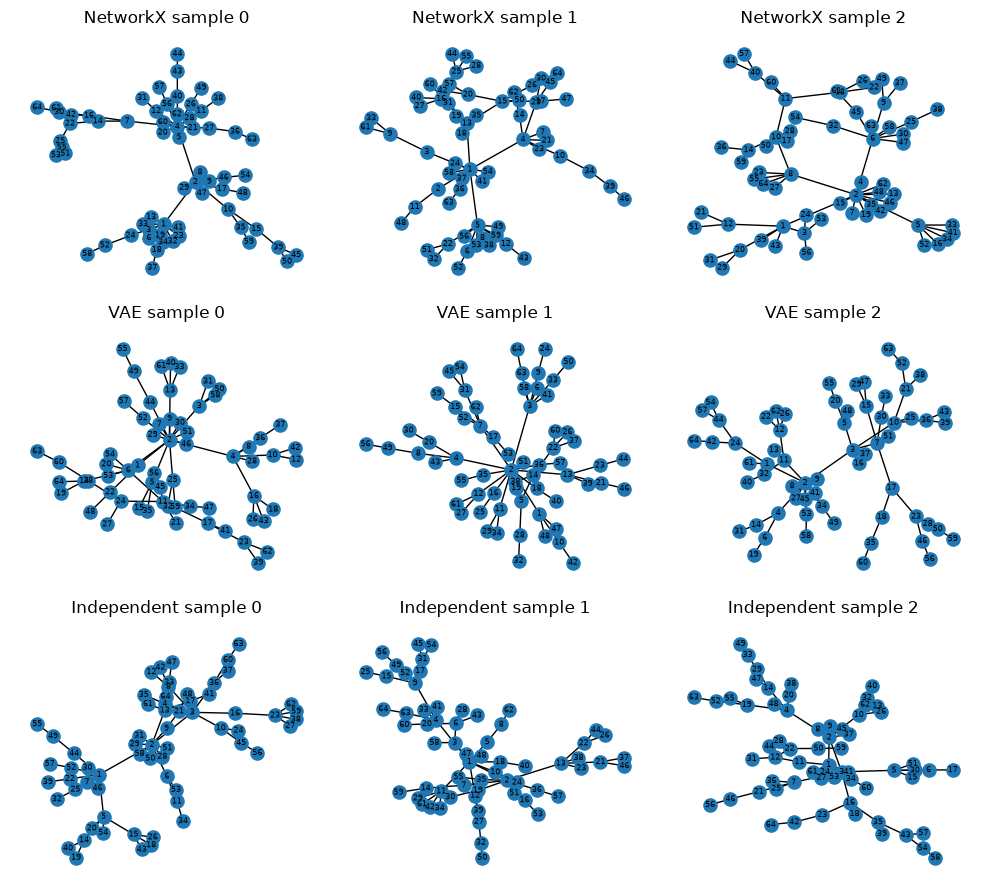

Hub/leaf summary: {
  "NetworkX": {
    "max_degree_mean": 14.8525390625,
    "max_degree_sd": 4.396772420219343,
    "leaf_fraction_mean": 0.6559219360351562,
    "leaf_fraction_sd": 0.0412165146259532
  },
  "VAE": {
    "max_degree_mean": 14.80810546875,
    "max_degree_sd": 4.523919247586145,
    "leaf_fraction_mean": 0.6237869262695312,
    "leaf_fraction_sd": 0.045190450154988356
  },
  "Independent": {
    "max_degree_mean": 10.68310546875,
    "max_degree_sd": 1.9876678231762115,
    "leaf_fraction_mean": 0.5910186767578125,
    "leaf_fraction_sd": 0.03813813784536002
  }
}


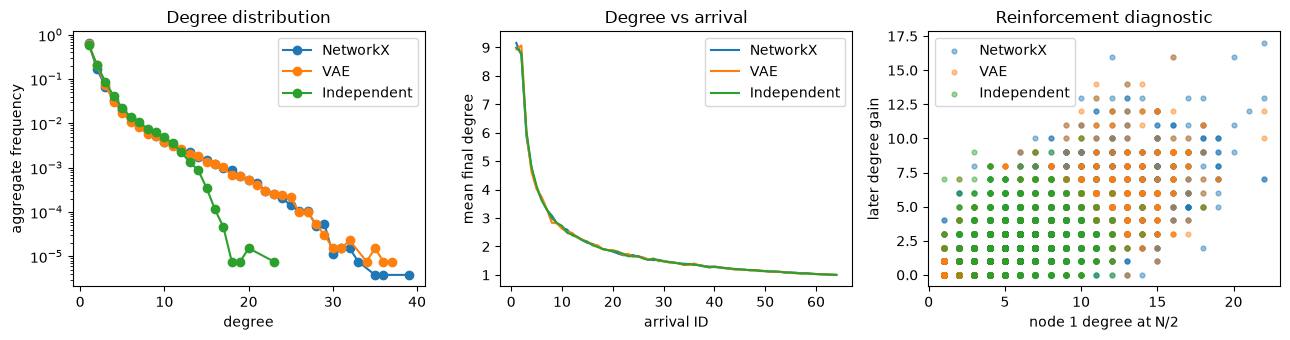

Reinforcement: {
  "NetworkX": {
    "pearson": 0.7076557006858957,
    "bootstrap_95pct": [
      0.6898471333084009,
      0.7228433664709281
    ],
    "undefined_resamples": 0
  },
  "VAE": {
    "pearson": 0.6958572827495908,
    "bootstrap_95pct": [
      0.6722004521976939,
      0.718508604877179
    ],
    "undefined_resamples": 0
  },
  "Independent": {
    "pearson": 0.001907798422769757,
    "bootstrap_95pct": [
      -0.04187026756991979,
      0.048827628728702444
    ],
    "undefined_resamples": 0
  }
}
{'median_scalar_query_ms_including_latent': np.float64(0.0937074992179987), 'median_public_full_graph_ms': np.float64(5.621937000796606), 'mean_networkx_full_graph_ms': 0.17869060011435067, 'timing_environment': {'device': 'cpu float32 public decoder', 'num_nodes': 64, 'threads': 8}}


In [ ]:
model.eval()

# === 1. run the model across test set to see reconstruction ability. mostly useful to compare to other models
with torch.no_grad():
    test_parents = test_p.to(device)
    latent_mean, _ = model.encode(test_parents)
    _, masked_logits, _ = model.decode(
        latent_mean, torch.arange(3, cfg.num_nodes + 1, device=device)
    )
    target_parents = test_parents[:, 2:] - 1
    reconstruction_cross_entropy = functional.cross_entropy(
        masked_logits.flatten(0, 1), target_parents.flatten(), reduction="mean"
    ).item()
    reconstruction_accuracy = (
        (masked_logits.argmax(-1) == target_parents).float().mean().item()
    )
print(
    {
        "mean_latent_test_parent_accuracy": reconstruction_accuracy,
        "mean_latent_test_cross_entropy": reconstruction_cross_entropy,
        "note": "reconstruction diagnostic; not fresh generation or marginal likelihood",
    }
)

# === 2. generate fresh graphs and compare to NetworkX and independent baseline

fresh_seeds = range(3_000_000, 3_000_000 + cfg.generated_graphs)
collections = {
    "NetworkX": [parents_to_graph(parents.numpy()) for parents in test_p],
    "VAE": [generator.graph(seed) for seed in fresh_seeds],
    "Independent": [baseline.graph(seed) for seed in fresh_seeds],
}

# draw some nice pictures of some
figure, axes = plt.subplots(3, 3, figsize=(10, 9))
for row_index, (collection_name, graphs) in enumerate(collections.items()):
    for column_index, graph in enumerate(graphs[:3]):
        nx.draw(
            graph,
            nx.spring_layout(graph, seed=71),
            ax=axes[row_index, column_index],
            node_size=90,
            with_labels=True,
            font_size=6,
        )
        axes[row_index, column_index].set_title(
            f"{collection_name} sample {column_index}"
        )
plt.tight_layout()
plt.show()

# === 3. compute some statistics and plots for the three collections
# maximum degree - the degree of the most connected node in a graph; size of the biggest hub
# max_degree_mean - the average maximum degree across all graphs in a collection
# max_degree_sd - the sample standard deviation of maximum degree across all graphs in a collection; how much the largest-hub size varies across graphs in a collection
# leafs are terminal nodes:
# leaf_fraction_mean - the average fraction of leaves across all graphs in a collection; number leaves/ total nodes
# leaf_fraction_sd - the sample standard deviation of leaf fraction across all graphs in a collection; how much the number of leaves varies across graphs in a collection

def graph_stats(graphs):
    maximum_degrees = np.array(
        [max(dict(graph.degree()).values()) for graph in graphs], float
    )
    leaf_fractions = np.array(
        [
            sum(degree == 1 for _, degree in graph.degree()) / len(graph)
            for graph in graphs
        ],
        float,
    )
    degrees_by_arrival = np.array(
        [
            [graph.degree(node) for node in range(1, cfg.num_nodes + 1)]
            for graph in graphs
        ],
        float,
    )
    return maximum_degrees, leaf_fractions, degrees_by_arrival


figure, axes = plt.subplots(1, 3, figsize=(13, 3.5))
summary = {}
for collection_name, graphs in collections.items():
    maximum_degrees, leaf_fractions, degrees_by_arrival = graph_stats(graphs)
    summary[collection_name] = {
        "max_degree_mean": maximum_degrees.mean(),
        "max_degree_sd": maximum_degrees.std(ddof=1),
        "leaf_fraction_mean": leaf_fractions.mean(),
        "leaf_fraction_sd": leaf_fractions.std(ddof=1),
    }
    degrees = [degree for graph in graphs for _, degree in graph.degree()]
    values, counts = np.unique(degrees, return_counts=True)
    axes[0].plot(values, counts / counts.sum(), marker="o", label=collection_name)
    axes[1].plot(
        range(1, cfg.num_nodes + 1),
        degrees_by_arrival.mean(0),
        label=collection_name,
    )
axes[0].set(xlabel="degree", ylabel="aggregate frequency", title="Degree distribution")
axes[0].set_yscale("log")
axes[0].legend()
axes[1].set(xlabel="arrival ID", ylabel="mean final degree", title="Degree vs arrival")
axes[1].legend()
print("Hub/leaf summary:", json.dumps(summary, indent=2))


def reinforcement(graphs):
    midpoint = cfg.num_nodes // 2
    midpoint_degrees = []
    later_degree_gains = []
    for graph in graphs:
        final_degree = graph.degree(1)
        midpoint_degree = graph.subgraph(range(1, midpoint + 1)).degree(1)
        midpoint_degrees.append(midpoint_degree)
        later_degree_gains.append(final_degree - midpoint_degree)
    return np.asarray(midpoint_degrees, float), np.asarray(later_degree_gains, float)


def correlation(first_values, second_values):
    if first_values.std() == 0 or second_values.std() == 0:
        return None
    return float(np.corrcoef(first_values, second_values)[0, 1])


eval_rng = np.random.default_rng(8675309)
corr_report = {}
for collection_name, graphs in collections.items():
    midpoint_degrees, later_degree_gains = reinforcement(graphs)
    pearson_correlation = correlation(midpoint_degrees, later_degree_gains)
    bootstrap_correlations = []
    undefined = 0
    for _ in range(200):
        sample_indices = eval_rng.integers(
            0, len(midpoint_degrees), len(midpoint_degrees)
        )
        bootstrap_correlation = correlation(
            midpoint_degrees[sample_indices], later_degree_gains[sample_indices]
        )
        if bootstrap_correlation is None:
            undefined += 1
        else:
            bootstrap_correlations.append(bootstrap_correlation)
    confidence_interval = (
        [float(bound) for bound in np.quantile(bootstrap_correlations, [0.025, 0.975])]
        if bootstrap_correlations
        else None
    )
    corr_report[collection_name] = {
        "pearson": pearson_correlation,
        "bootstrap_95pct": confidence_interval,
        "undefined_resamples": undefined,
    }
    axes[2].scatter(
        midpoint_degrees,
        later_degree_gains,
        s=12,
        alpha=0.45,
        label=collection_name,
    )
axes[2].set(
    xlabel="node 1 degree at N/2",
    ylabel="later degree gain",
    title="Reinforcement diagnostic",
)
axes[2].legend()
plt.tight_layout()
plt.show()
print("Reinforcement:", json.dumps(corr_report, indent=2))

for _ in range(5):
    generator.parent(123, 10)
query_times = []
graph_times = []
for _ in range(50):
    query_started = time.perf_counter()
    generator.parent(123, 10)
    query_times.append(time.perf_counter() - query_started)
for seed_offset in range(10):
    graph_started = time.perf_counter()
    generator.graph(9_000_000 + seed_offset)
    graph_times.append(time.perf_counter() - graph_started)
simulation_started = time.perf_counter()
for seed_offset in range(10):
    simulate_graph(cfg.num_nodes, 8_000_000 + seed_offset)
networkx_time = (time.perf_counter() - simulation_started) / 10
print(
    {
        "median_scalar_query_ms_including_latent": 1e3 * np.median(query_times),
        "median_public_full_graph_ms": 1e3 * np.median(graph_times),
        "mean_networkx_full_graph_ms": 1e3 * networkx_time,
        "timing_environment": {
            "device": "cpu float32 public decoder",
            "num_nodes": cfg.num_nodes,
            "threads": cfg.threads,
        },
    }
)

## Interpretation and next experiment

The notebook reports implementation correctness separately from learned quality. Structural
validity is guaranteed by the parent representation and does not show that preferential
attachment was learned. Compare VAE and independent-parent reinforcement correlations, hub
variation, leaves, and degree-by-age against held-out NetworkX samples. With only two smoke-test
epochs, weak fidelity is expected and is not an implementation failure. Run the documented demo
configuration before drawing empirical conclusions. The largest uncertainty is whether a fixed
global latent preserves graph-specific reinforcement as N grows; next compare latent capacities,
then a hierarchical/Pólya-urn-inspired representation under the same query-cost accounting.

References: [Doersch](https://arxiv.org/abs/1606.05908), [Kingma & Welling](https://arxiv.org/abs/1312.6114),
[GraphVAE](https://arxiv.org/abs/1802.03480), [Guzmán et al.](https://arxiv.org/abs/2105.00997),
[Even et al.](https://arxiv.org/abs/1602.06159), and [O'Bray et al.](https://arxiv.org/abs/2106.01098).

further analysis to do here:
- I want to look at structural consistency, that's the big thing. Can I query seperate points with the same seed and reconstruct it proeprly?

Looks like we are already doing this with those constructed graphs. It make sense that you CAN do this and get consistent results each time you query, the question is: when idependently queried answers are assembled, does the resulting graph exhibit the dependencies of preferential attachment.

It looks like we are forcing the result to have properties like: connectivity, a valid tree, each parent is older than its child, every non-root node has exactly one parent. This is done from masking and construction. One question to ask is: is this cheating? in this application it doesn't feel like it, because this is an easy way to set bounds on the generation. It's more interesting to see if the resulting distribution can match the behavior we want, which is the next point, I want to test this more deeply.

- I want to look at whether the distribution of graphs matches what you would expect for these growth graphs. We kinda did that here...but not super strongly. Need to flesh out what tha tmeans. What are the barbas-albert lasws we want to observe?

degree distribution

hub growth over time

artificial-time-degree relations.

- I want a different baseline, just some simple model like a markov model, that I can also compare against.